#### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,MinMaxScaler
from sklearn.naive_bayes import GaussianNB


#### Load Data

    Loan_ID Gender Married  ... Credit_History Property_Area Loan_Status
0  LP001002   Male      No  ...            1.0         Urban           Y
1  LP001003   Male     Yes  ...            1.0         Rural           N
2  LP001005   Male     Yes  ...            1.0         Urban           Y
3  LP001006   Male     Yes  ...            1.0         Urban           Y
4  LP001008   Male      No  ...            1.0         Urban           Y

[5 rows x 13 columns]
Null values in the dataset: Credit_History       8.143322
Self_Employed        5.211726
LoanAmount           3.583062
Dependents           2.442997
Loan_Amount_Term     2.280130
Gender               2.117264
Married              0.488599
Education            0.000000
Loan_ID              0.000000
CoapplicantIncome    0.000000
ApplicantIncome      0.000000
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64


<Axes: >

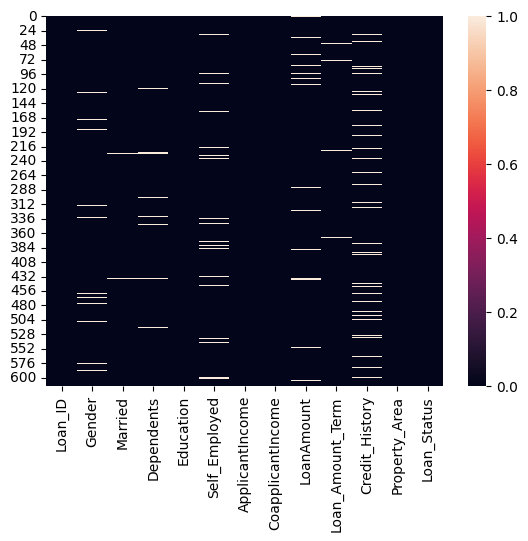

In [ ]:
df = pd.read_csv("loan_data_set.csv")
print(df.head())
null_values = df.isnull().sum()/len(df)*100
null_values = null_values.sort_values(ascending=False)
print(f"Null values in the dataset: {null_values}")
sns.heatmap(df.isnull())

### STAT Method to handling with null values

In [19]:
null_column = ["Credit_History", "LoanAmount", "Dependents", "Loan_Amount_Term"]
print(null_column)

for col in null_column:
    if df[col].dtype != 'object':  
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])  

categorical_columns = ["Self_Employed", "Gender","Married"]
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()


['Credit_History', 'LoanAmount', 'Dependents', 'Loan_Amount_Term']


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

### Normalize the Data

In [ ]:


categorical_columns = ["Loan_ID", "Gender", "Married", "Dependents", "Education", "Self_Employed", "Property_Area", "Loan_Status"]
label_encoder = LabelEncoder()
for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])
df.head()
scaler = MinMaxScaler()
numerical_columns = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term", "Credit_History"]
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])





### Training Dataset and using model

In [21]:
from sklearn.metrics import accuracy_score,r2_score,confusion_matrix
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.75,random_state=0)
model = GaussianNB()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_pred,y_test)
r2 = r2_score(y_pred,y_test)
confusion = confusion_matrix(y_pred,y_test)

print(f"Accuracy score of dataset is : {accuracy:.2f}")
print(f"R2 score of dataset is : {r2:.2f}")


Accuracy score of dataset is : 0.82
R2 score of dataset is : -0.33


### Visualization of dataset

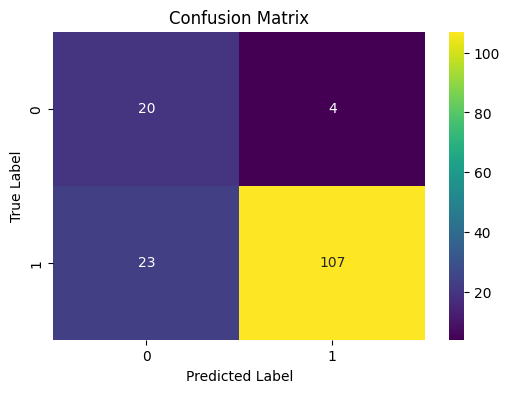

In [22]:
plt.figure(figsize=(6, 4))

sns.heatmap(confusion, annot=True, fmt="d", cmap="viridis", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()